# Week 1: `make_moons` active-learning sanity check

We reveal six labels, fit a GP regressor to labels in `{-1, +1}`, and repeatedly query the pool point nearest the believed boundary: `argmin |mu(x)|`. The initial design contains three random points from each class so that the first GP sees both regimes.

In [4]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.make_moons_sanity_check import run_experiment, save_results

In [5]:
result = run_experiment(seed=0, initial_size=6, total_budget=50)
save_results(result, ROOT / 'outputs' / 'make_moons')
{n: round(float(s['uncertain_fraction']), 4) for n, s in result.snapshots.items()}

{6: 0.8208, 20: 0.5639, 50: 0.3092}

The credible-region area is the fraction of the unit square satisfying `|mu(x)| <= 1.96 sigma(x)`. It is a simple, inspectable proxy for posterior uncertainty around the level set. The colour display is derived from the GP latent mean for visualization; it is not a calibrated class probability.

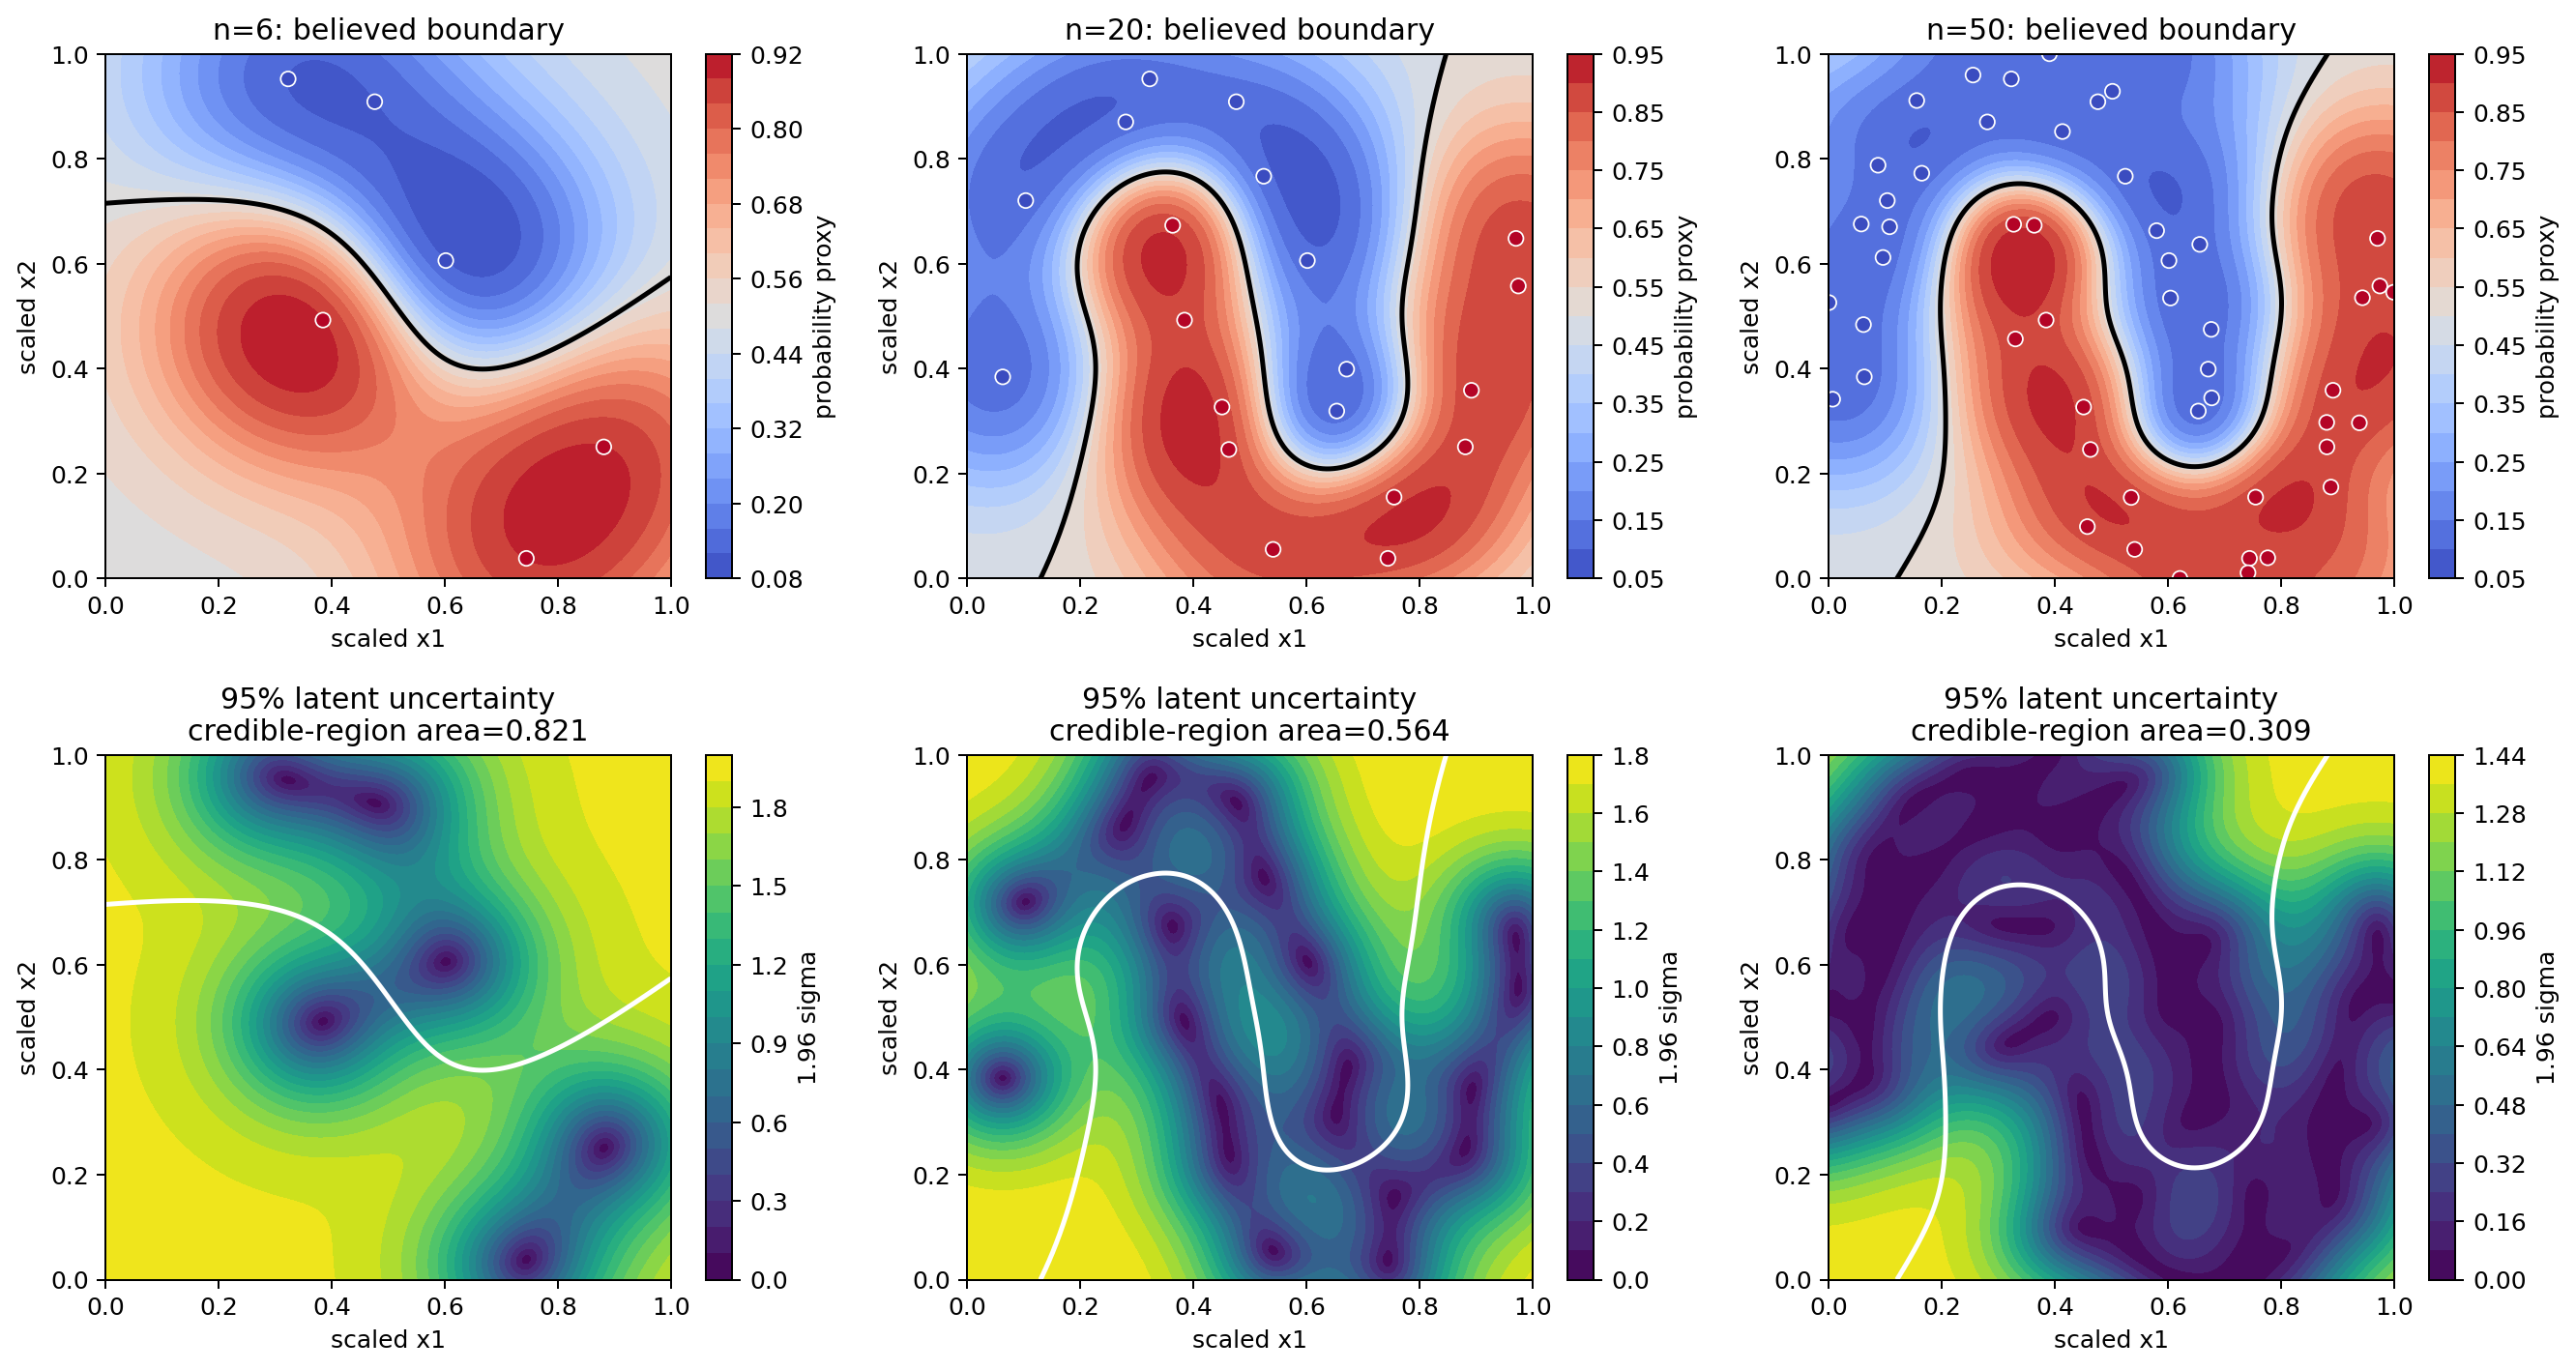

In [6]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'outputs' / 'make_moons' / 'boundary_contraction.png')))